# Deconvolve the origins of replication

June 25, 2024

## Goal:
Deconvolve the origins of replication and show 1-2 great examples.

Procedure:
1. Load the chromatin deconvolution model.
2. Add a function to load the mnase and bins for the origin of replication

Note:
- We don't have the copy number correction scaling factor yet, it should not have a big effect on the chromatin, but something to keep in mind and place on the to do list.


In [459]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [460]:
from src.config import load_combined_gene_expression_by_config_type,\
    load_configs_by_config_type

config_type = 'shared'

chrom_config1, chrom_config2 = load_configs_by_config_type(config_type,
    with_copy_correction=True)

In [461]:
from src.combined_chromatin_model import CombinedChromatinModel

combined_model = CombinedChromatinModel(chrom_config1, chrom_config2)

In [462]:
combined_model.load_combined_mnase_orc('ARS1623')

Applying a normalization for length distribution
Applying a normalization for length distribution


In [463]:
combined_model.setup_deconv_model()

In [464]:
combined_model.deconvolve()

Deconvolving combined model with gamma=0.006
Deconvolving bin size: 11x11
of G shape: (31, 4117)
Deconvolving with gamma=0.006
0/4117 - 00:00:00.152
100/4117 - 00:00:08.379
200/4117 - 00:00:15.544
300/4117 - 00:00:22.627
400/4117 - 00:00:29.590
500/4117 - 00:00:36.505
600/4117 - 00:00:43.281
700/4117 - 00:00:49.984
800/4117 - 00:00:56.462
900/4117 - 00:01:02.730
1000/4117 - 00:01:08.981
1100/4117 - 00:01:15.018
1200/4117 - 00:01:21.078
1300/4117 - 00:01:27.246
1400/4117 - 00:01:33.686
1500/4117 - 00:01:39.813
1600/4117 - 00:01:45.961
1700/4117 - 00:01:51.983
1800/4117 - 00:01:58.029
1900/4117 - 00:02:04.102
2000/4117 - 00:02:10.098
2100/4117 - 00:02:16.188
2200/4117 - 00:02:22.243
2300/4117 - 00:02:28.499
2400/4117 - 00:02:34.756
2500/4117 - 00:02:41.108
2600/4117 - 00:02:47.361
2700/4117 - 00:02:53.531
2800/4117 - 00:02:59.786
2900/4117 - 00:03:05.964
3000/4117 - 00:03:12.140
3100/4117 - 00:03:18.253
3200/4117 - 00:03:24.424
3300/4117 - 00:03:30.685
3400/4117 - 00:03:36.891
3500/4117 

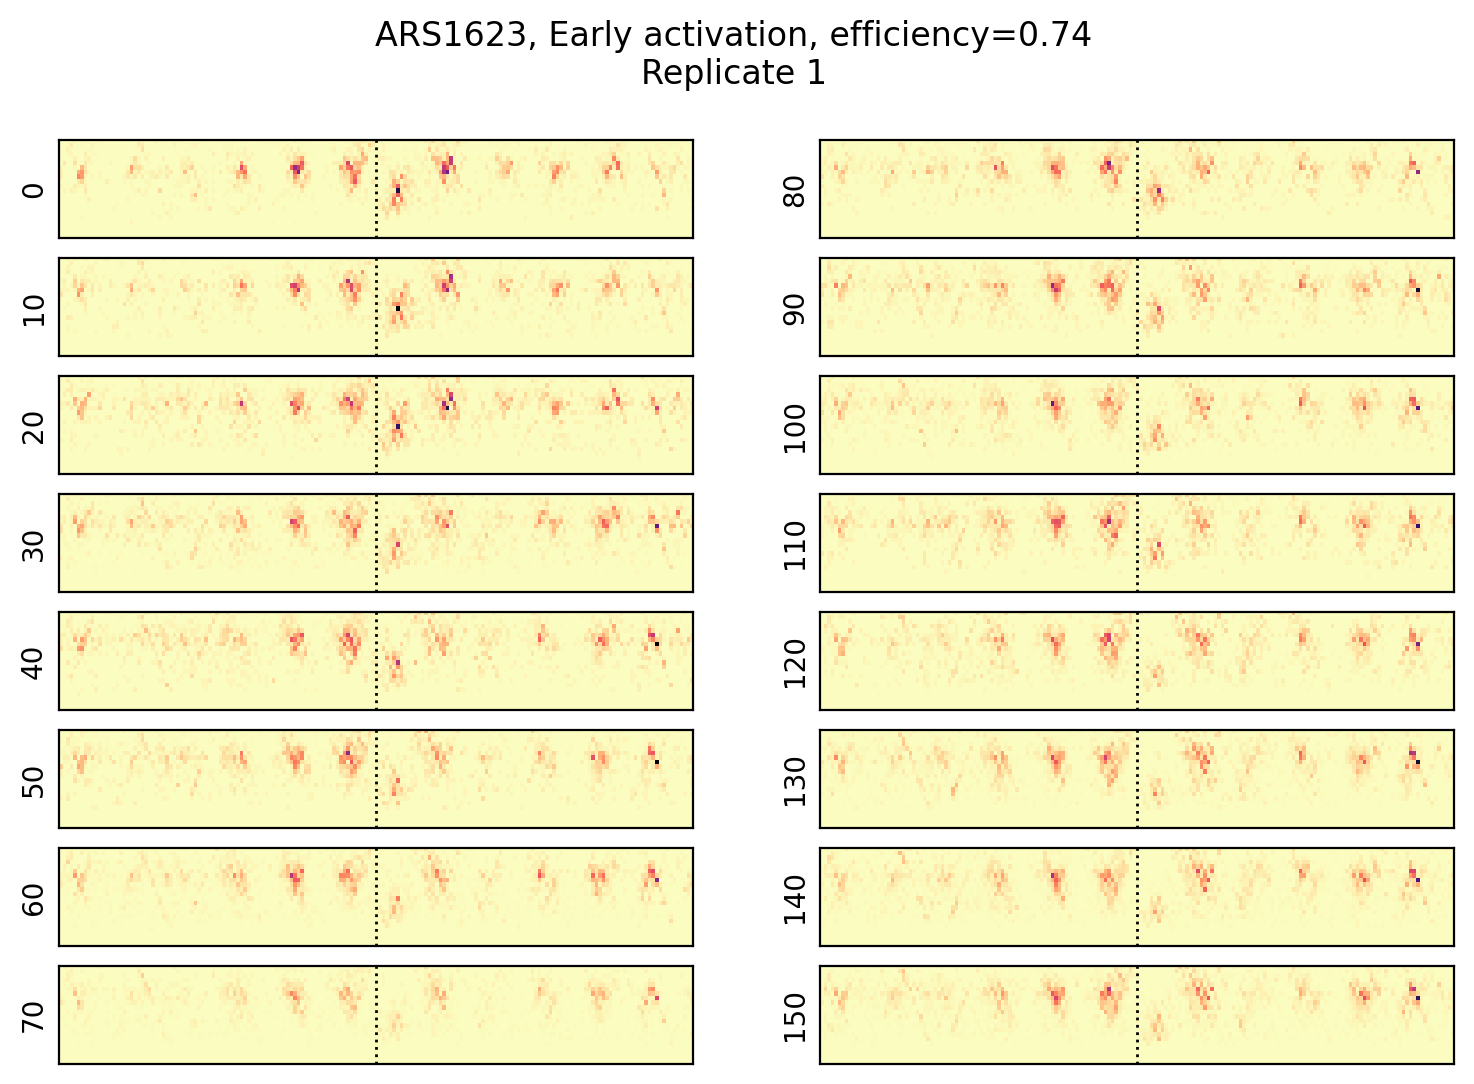

In [468]:
fig = combined_model.plot_raw_origin_data(1, vmax=50)

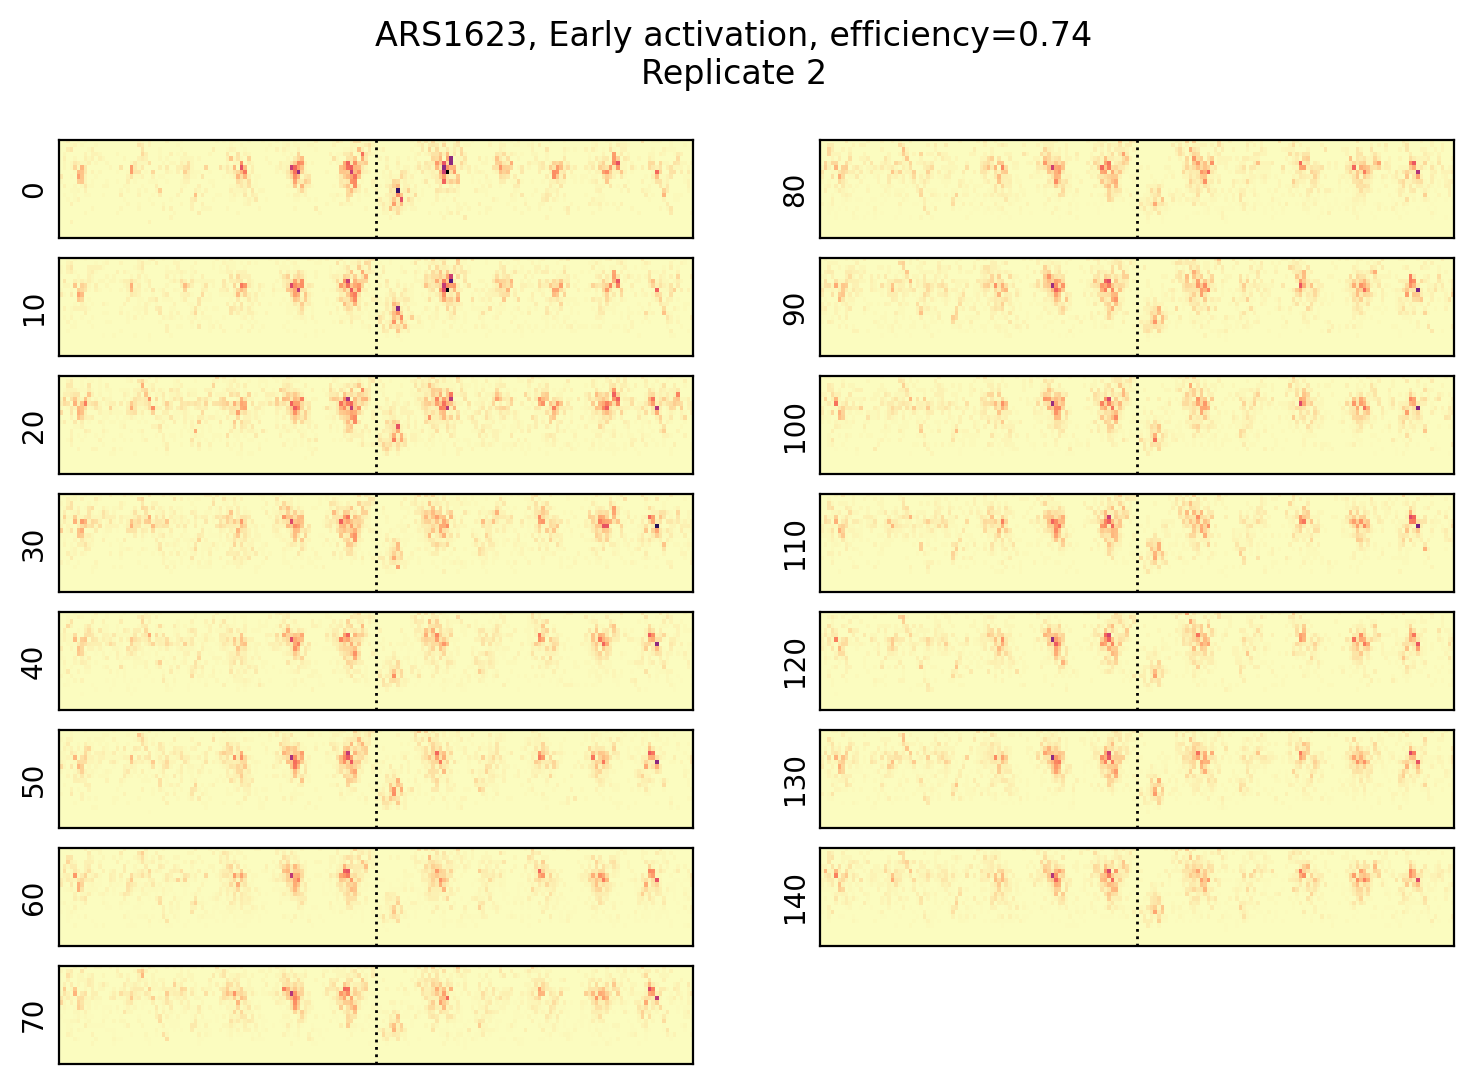

In [469]:
fig = combined_model.plot_raw_origin_data(2, vmax=50)

In [479]:
combined_model.find_origin_p1_and_m1_nucleosome_position()

Nucleosomal fragment length range:  (144, 192)
Origin fragment length range:  (11, 107)
The +1 span for tracking is: (633926, 634278)  length:  352
The -1 span for tracking is: (633574, 633926)  length:  352
The span for origin occupancy is: (633805, 634047)  length:  242
Nucleosomal fragment length range:  (144, 192)
Origin fragment length range:  (11, 107)
The +1 span for tracking is: (633926, 634278)  length:  352
The -1 span for tracking is: (633574, 633926)  length:  352
The span for origin occupancy is: (633805, 634047)  length:  242


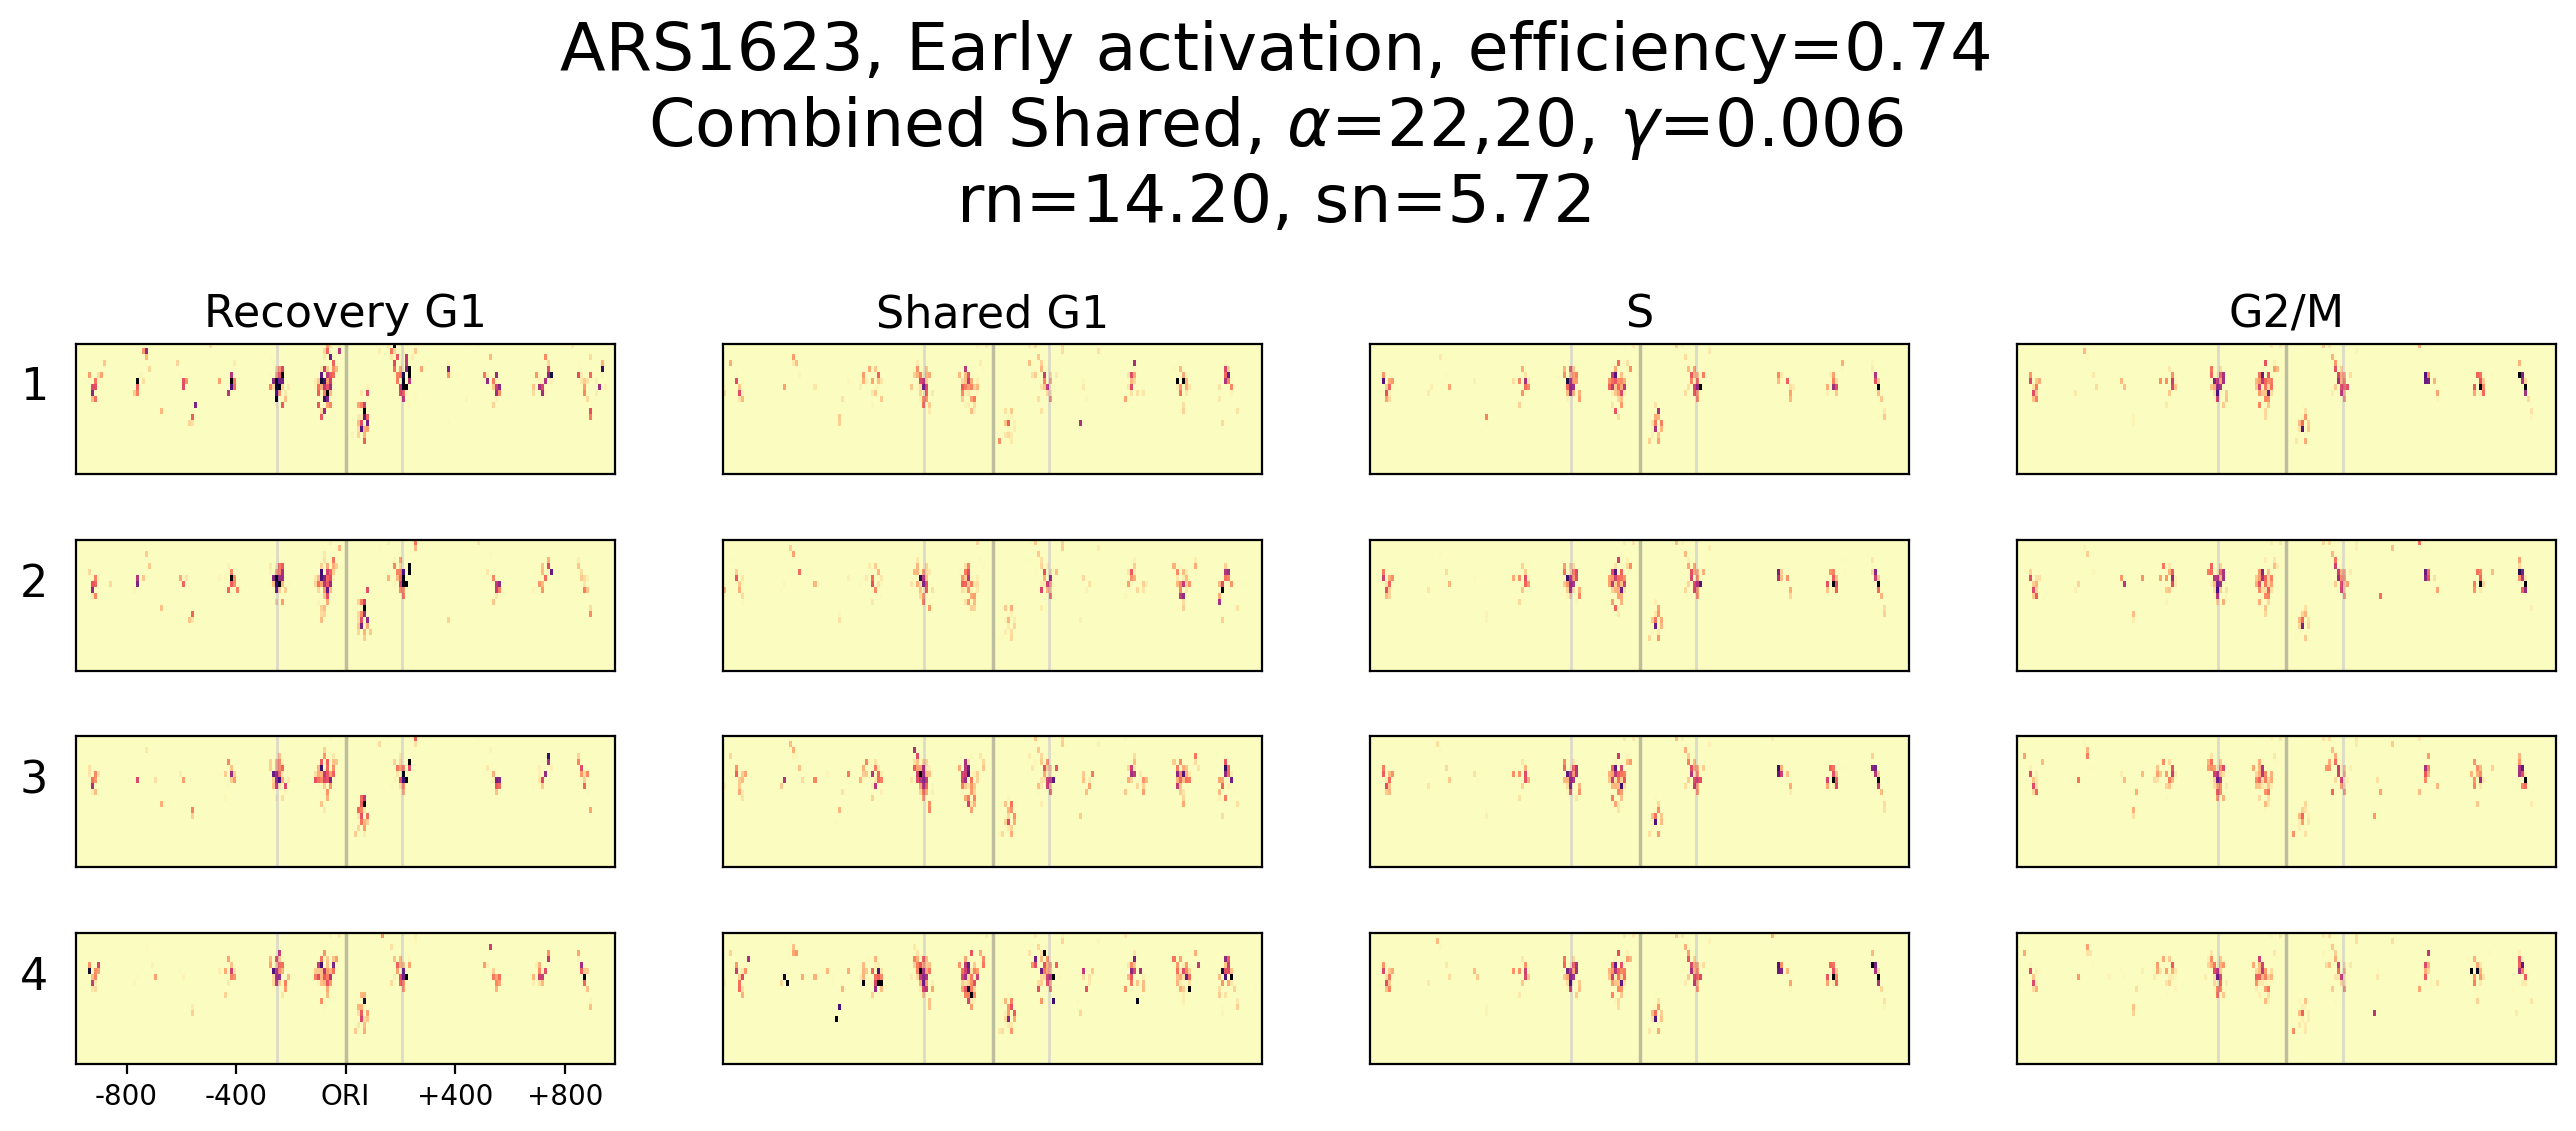

In [482]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=25)

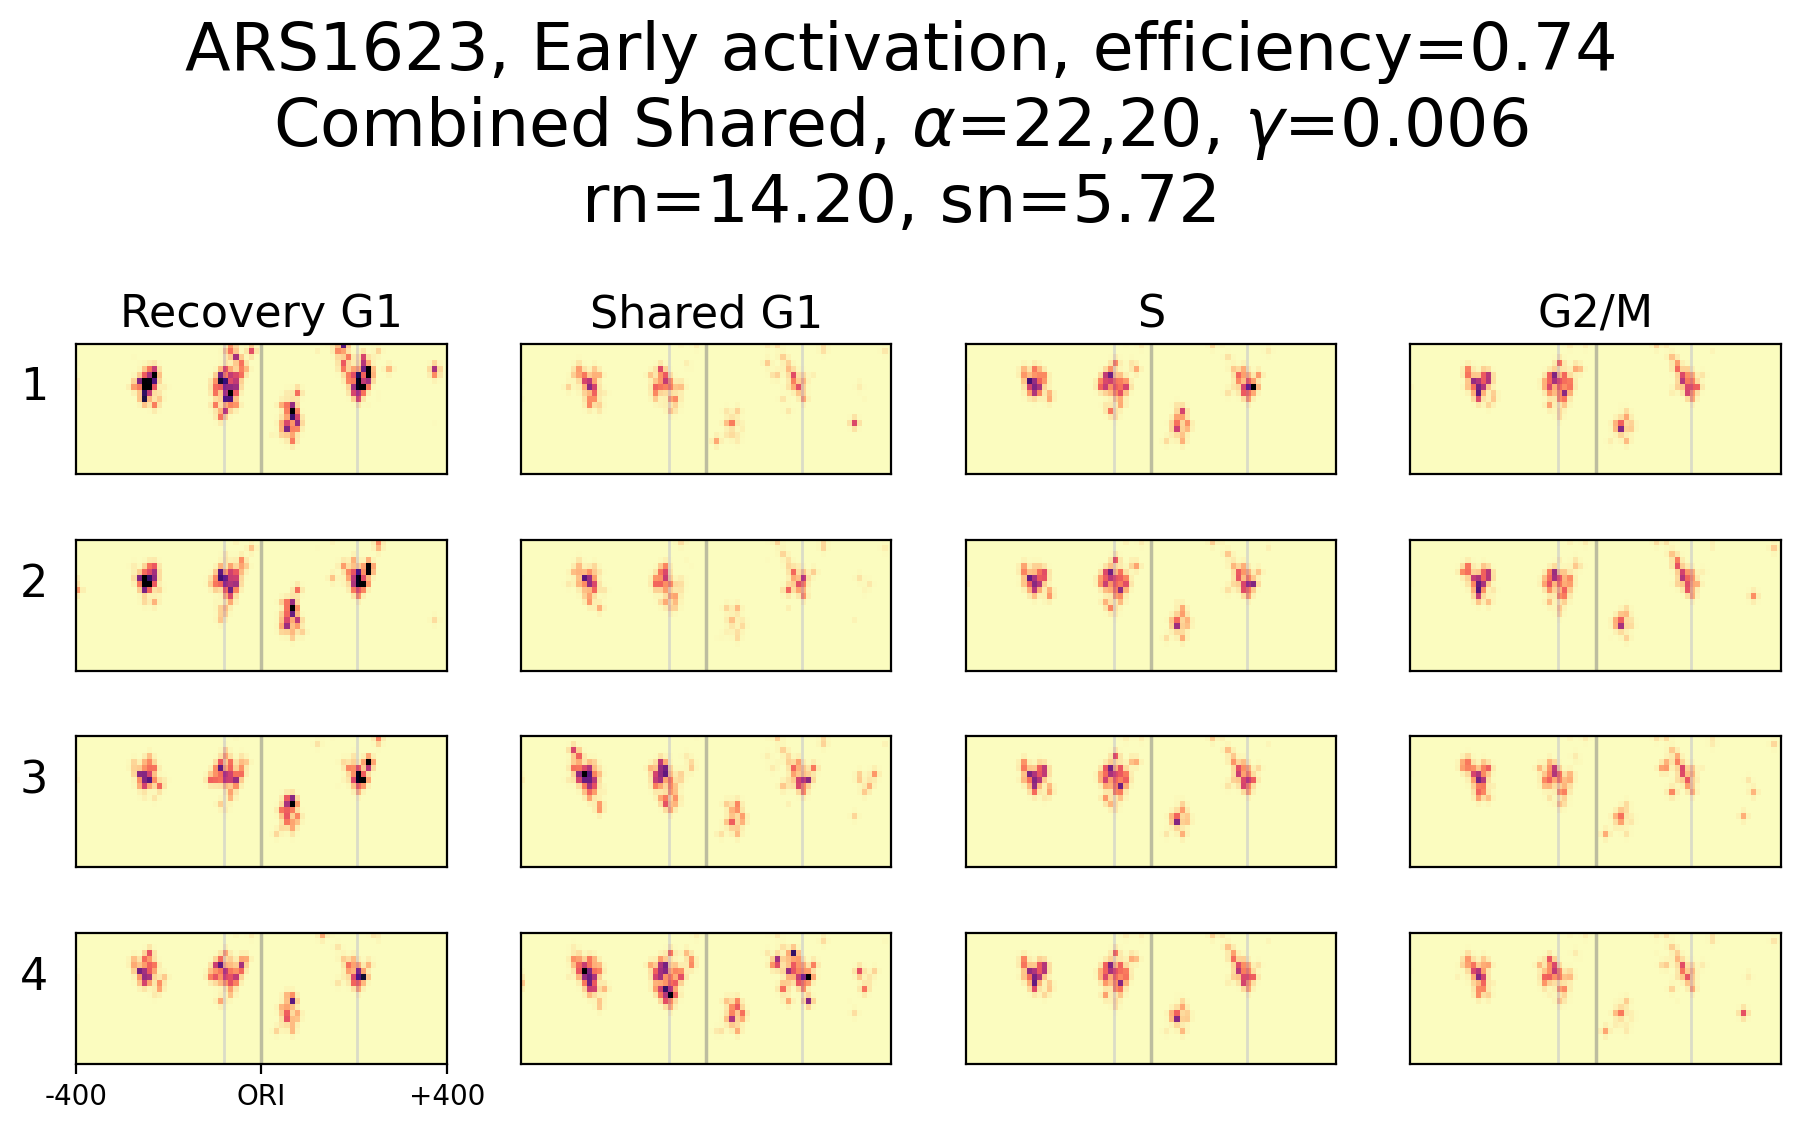

In [505]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(zoom=800, vmax=20,
                                                                   num_rows=4,
    should_smooth_data=True)


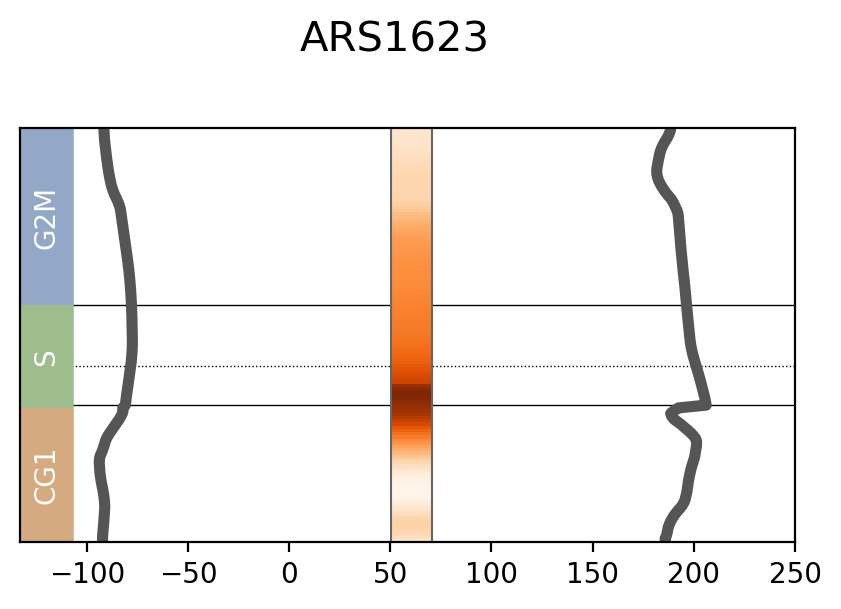

In [495]:
fig = combined_model.chrom1_model.plot_nfr_shift_origin_occupancy()

In [493]:
combined_model.find_origin_p1_and_m1_nucleosome_position()

Nucleosomal fragment length range:  (144, 192)
Origin fragment length range:  (11, 107)
(-142, 0)
The +1 span for tracking is: (633926, 634168)  length:  242
The -1 span for tracking is: (633783, 633926)  length:  143
The span for origin occupancy is: (633805, 634047)  length:  242
Nucleosomal fragment length range:  (144, 192)
Origin fragment length range:  (11, 107)
(-142, 0)
The +1 span for tracking is: (633926, 634168)  length:  242
The -1 span for tracking is: (633783, 633926)  length:  143
The span for origin occupancy is: (633805, 634047)  length:  242


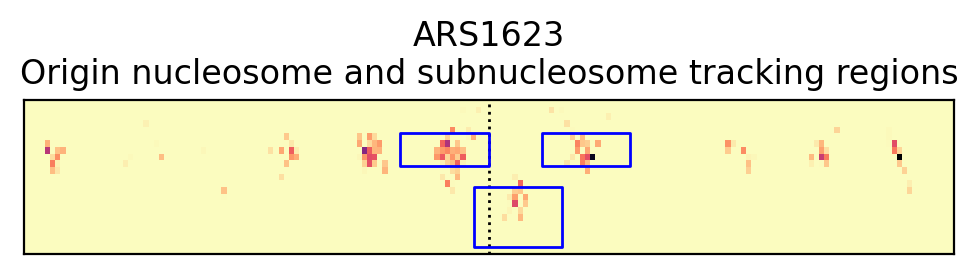

In [494]:
fig = combined_model.chrom1_model.plot_origin_trackers()